Figure1: 

climatology of blocks and tracks as upper panel. Blocking frequecny (%): contours; track points: plot the genenis points and the first interacting points (color represent the entry time percentage)

and timing as histogram as the inner panel. Only focus on anticylones and Ridge blocks. 


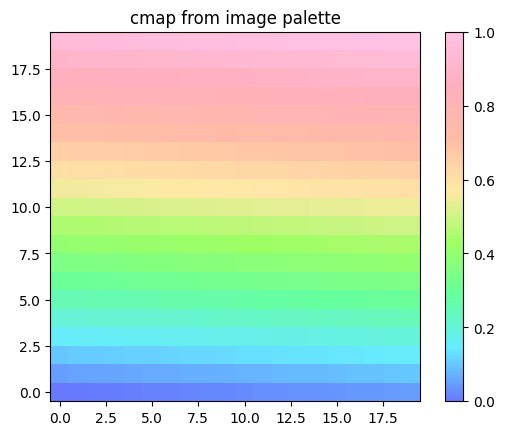

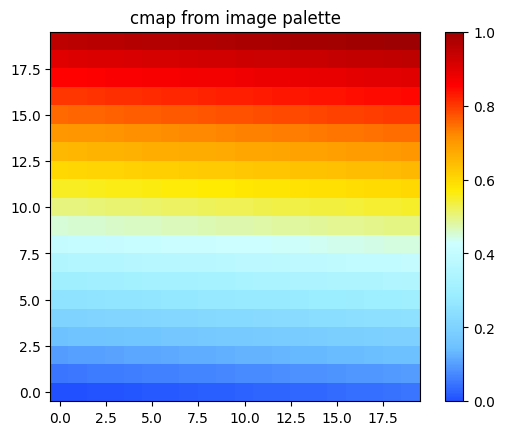

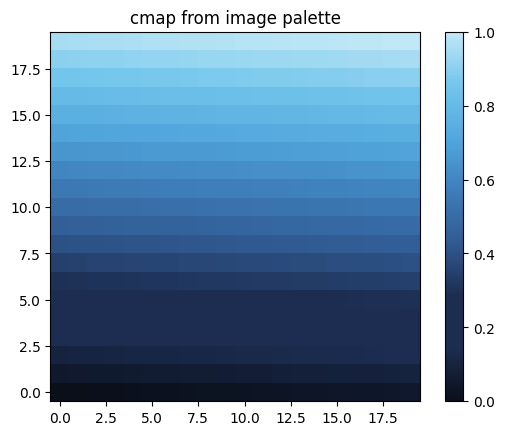

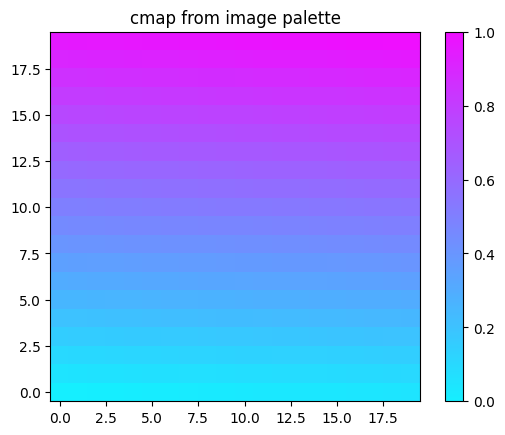

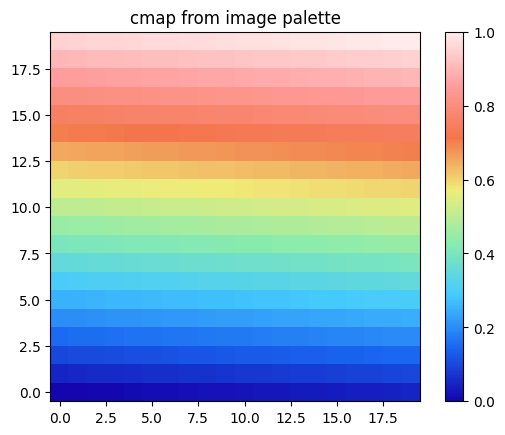

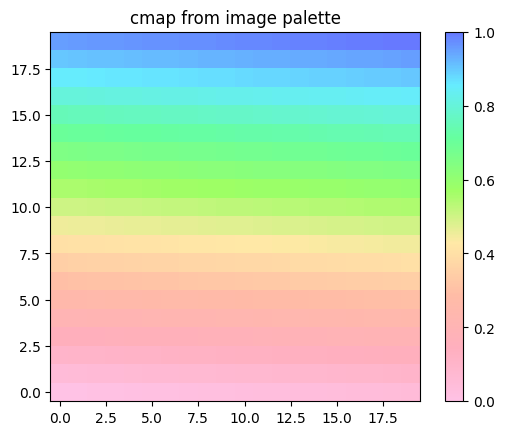

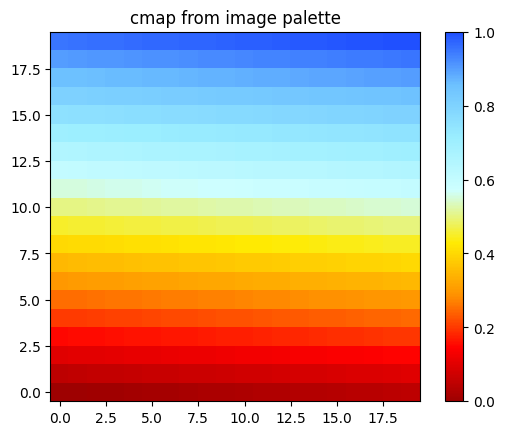

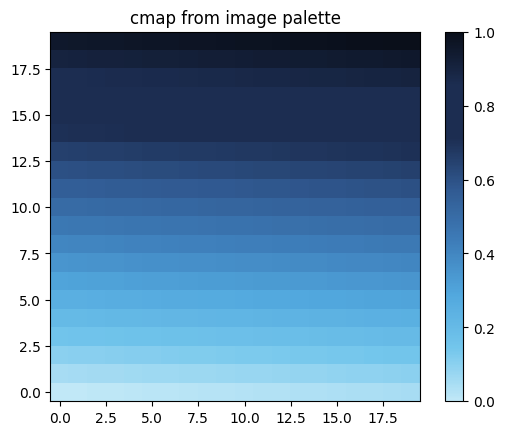

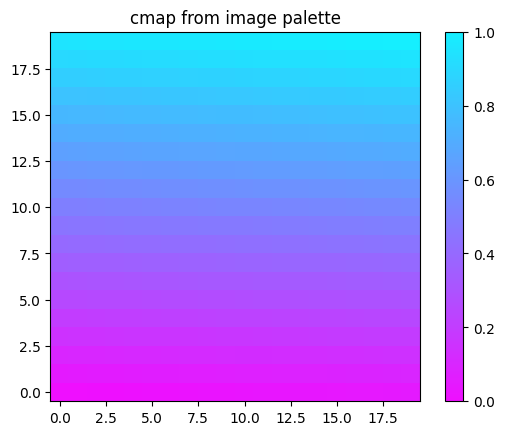

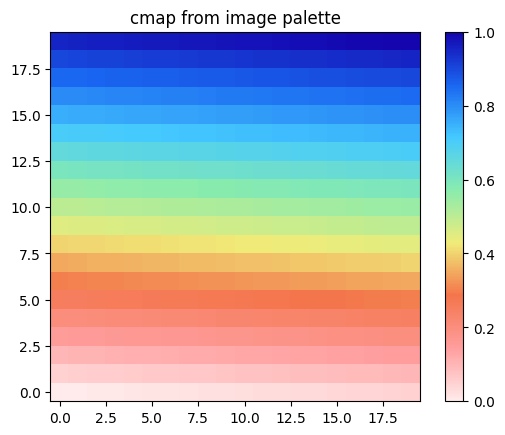

In [1]:
import numpy as np
import datetime as dt
from datetime import date
from datetime import datetime
from matplotlib import pyplot as plt
import cmocean
# from HYJfunction import *
import math
import time

from netCDF4 import Dataset
import pandas as pd
from dateutil.relativedelta import relativedelta
import matplotlib.colors
import os
import cartopy
from cartopy import crs as ccrs
import matplotlib.ticker as mticker
import matplotlib.ticker as ticker
from scipy import ndimage
from multiprocessing import Pool, Manager
import cartopy.feature as cfeature
from scipy.ndimage import convolve
from scipy.signal import detrend
import pickle
import xarray as xr
import regionmask
from matplotlib.patches import Polygon
import matplotlib.path as mpath
from matplotlib.lines import Line2D
from multiprocessing import Pool, Manager
from matplotlib.colors import BoundaryNorm, ListedColormap
import seaborn as sns
import imageio
from scipy import stats
from collections import defaultdict
from scipy.ndimage import label
from scipy.interpolate import interp2d
import sys
import os
from cartopy.util import add_cyclic_point
import gmtColors

# %% function --------------------------------
regions = ["ATL", "NP", "SP"]
seasons = ["DJF", "JJA", "ALL"]
seasonsmonths = [[12, 1, 2], [6, 7, 8], [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]]
blkTypes = ["Ridge", "Trough", "Dipole"]
cycTypes = ["CC", "AC"]
eventType = ["Blocking", "Seeding"]

def Region_ERA(regionname): 
    if regionname == "ATL": 
        lat_min, lat_max, lon_min, lon_max = 45, 75, 300, 60
    elif regionname == "NP": 
        lat_min, lat_max, lon_min, lon_max = 40, 70, 130, 250
    elif regionname == "SP": 
        lat_min, lat_max, lon_min, lon_max = -75, -45, 180, 300
    return lat_min, lat_max, lon_min, lon_max

def findClosest(lati, latids):

    if isinstance(lati, (np.ndarray, list)):  # if lat is an array or list
        closest_indices = []
        for l in lati:  
            diff = np.abs(l - latids)
            closest_idx = np.argmin(diff) 
            closest_indices.append(closest_idx)
        return closest_indices
    else:
        # if lat is a single value
        diff = np.abs(lati - latids)
        return np.argmin(diff) 

def getSectorValues(data, lat_min, lat_max, lon_min, lon_max, lat, lon):
    lat_indices = (lat >= lat_min) & (lat <= lat_max)
    lon_indices = (lon >= lon_min) & (lon <= lon_max)
    if lon_min > lon_max:
        lon_indices = (lon >= lon_min) | (lon <= lon_max)
    lat_indices = np.where(lat_indices)[0]
    lon_indices = np.where(lon_indices)[0]

    lat_indices, lon_indices = np.ix_(lat_indices, lon_indices)

    region_mask = np.zeros_like(data, dtype=bool)
    region_mask[:, lat_indices, lon_indices] = True

    data_filtered = np.where(region_mask, data, 0)

    return region_mask[0,:,:], data_filtered


In [ ]:

def create_Map(lon, lat, M, minv, maxv, interv=7, continterv = None, fill=True, ax=None, 
               leftlon=-180, rightlon=180, lowerlat=20, upperlat=90, centralLon=0, extend='both', alpha=1,
               fig=None, nrows=1, ncols=1, index=1, figsize=(15, 18),
               colr='coolwarm',contourcolr='gray', title=None, axisfontsize=12):

    import matplotlib.pyplot as plt
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    import xarray as xr
    import numpy as np
    from matplotlib.patches import Polygon
    import matplotlib.path as mpath
    from matplotlib.lines import Line2D

    # lon = ((lon + 180) % 360) - 180
    # lon = lon-180
    proj = ccrs.PlateCarree(central_longitude=centralLon)
    img_extent = [leftlon, rightlon, lowerlat, upperlat]
    # If not provided, create a new figure
    if fig is None:
        fig = plt.figure(figsize=figsize)   
    if ax == None:
        ax = fig.add_subplot(nrows, ncols, index, projection = proj)
        ax.set_extent(img_extent, ccrs.PlateCarree())
        ax.add_feature(cfeature.COASTLINE.with_scale('110m'))
        gl = ax.gridlines(crs=ccrs.PlateCarree(), draw_labels=True, linewidth=1, 
                          color='gray', linestyle='--', alpha=0.5)
        gl.xlabel_style = {'size': axisfontsize}
        gl.ylabel_style = {'size': axisfontsize}

    if fill==True:
        cf = ax.contourf(lon,lat,M,transform=ccrs.PlateCarree(),cmap=colr,levels=np.linspace(minv, maxv, interv), extend=extend, alpha=alpha)
    else:
        cf = ax.contour(lon,lat,M,transform=ccrs.PlateCarree(),colors=contourcolr,levels=np.arange(minv, maxv+continterv, continterv), negative_linestyles = 'dashed')
        ax.clabel(cf, inline=True, fontsize=8, fmt='%1.1f', colors=contourcolr, use_clabeltext=True)

    if title:
        ax.set_title(title)
    
    plt.tight_layout()
    
    return fig, ax, cf


def addSegments(ax,points,colr='black',linewidth=2,labels=None,alpha=1,linestyle='solid', zorder=4):
    import matplotlib.pyplot as plt
    import cartopy.crs as ccrs
    import cartopy.feature as cfeature
    import xarray as xr
    import numpy as np
    from matplotlib.patches import Polygon
    import matplotlib.path as mpath
    from matplotlib.lines import Line2D
    
    # segments = []
    # for i in range(len(points) - 1):
    #     segment = [points[i], points[i + 1]]
    #     segments.append(segment)

    segments = []
    for i in range(len(points) - 1):
        lon1, lat1 = points[i]
        lon2, lat2 = points[i + 1]
        if lon1<0 or lon2<0:
            print('Longitude should be within 0-360 degrees')
        # if the longitude crosses 0 degrees, we need to split the line into two segments
        if abs(lon1 - lon2) > 180:
            
            lonm1 = 0 if lon1 < abs(360 - lon1) else 360
            lonm2 = 0 if lon2 < abs(360 - lon2) else 360
            segments.append([(lon1, lat1), (lonm1, (lat1+lat2)/2)])
            segments.append([(lonm2, (lat1+lat2)/2), (lon2, lat2)])
        else:
            segments.append([(lon1, lat1), (lon2, lat2)])

    colr = [colr] * len(segments)
    
    for i, line_segment in enumerate(segments):
        
        lons = [p[0] for p in line_segment]
        lats = [p[1] for p in line_segment]        
        color = colr[i]  # get the color      
        line = Line2D(
            lons, lats, 
            color=color,  # set color
            linewidth=linewidth, 
            transform=ccrs.PlateCarree(),
            alpha=alpha,
            linestyle=linestyle,
            zorder=zorder
        )        
        ax.add_line(line)
        # if labels are provided, add them
        if labels is not None:
            # calculate the mid point of each segment
            mid_lon = (lons[0] + lons[1]) / 2
            mid_lat = (lats[0] + lats[1]) / 2
            # add the label
            ax.text(mid_lon, mid_lat, labels[i], fontsize=5, 
                ha='center', transform=ccrs.PlateCarree())


In [ ]:
datasets = ["ERA5", "MERRA2", "JRA3Q"]

OUT_DIR_List = {
    "ERA5": "/scratch/bell/hu1029/LGHW/interm_ERA5",
    "MERRA2": "/scratch/bell/hu1029/LGHW/interm_MERRA2",
    "JRA3Q": "/scratch/bell/hu1029/LGHW/interm_JRA3Q"
}
yearnameList = {
    "ERA5": "1979_2025",
    "MERRA2": "1980_2025",
    "JRA3Q": "1979_2025"
}
timerefFile = {
    "ERA5": "/scratch/bell/hu1029/Data/processed/ERA5_Z500_6hr_1979_2025_1dg.nc",
    "MERRA2": "/scratch/bell/hu1029/Data/processed/MERRA2_Z500_6hr_1980_2025_1dg.nc",
    "JRA3Q": "/scratch/bell/hu1029/Data/processed/JRA3Q_Z500_6hr_1979_2025_1dg.nc"
}
latrefFile = {
    "ERA5": "/scratch/bell/hu1029/LGHW/interm_ERA5/ERA5_LWA_lat_1979_2025_6hr.npy",
    "MERRA2": "/scratch/bell/hu1029/LGHW/interm_MERRA2/MERRA2_LWA_lat_1980_2025_6hr.npy",
    "JRA3Q": "/scratch/bell/hu1029/LGHW/interm_JRA3Q/JRA3Q_LWA_lat_1979_2025_6hr.npy"
}
lonrefFile = {
    "ERA5": "/scratch/bell/hu1029/LGHW/interm_ERA5/ERA5_LWA_lon_1979_2025_6hr.npy",
    "MERRA2": "/scratch/bell/hu1029/LGHW/interm_MERRA2/MERRA2_LWA_lon_1980_2025_6hr.npy",
    "JRA3Q": "/scratch/bell/hu1029/LGHW/interm_JRA3Q/JRA3Q_LWA_lon_1979_2025_6hr.npy"
}
TRACK_latrefFile = {
    "ERA5": "/scratch/bell/hu1029/LGHW/interm_ERA5/ERA5_TRACK_lat_1979_2025_6hr.npy",
    "MERRA2": "/scratch/bell/hu1029/LGHW/interm_MERRA2/MERRA2_TRACK_lat_1980_2025_6hr.npy",
    "JRA3Q": "/scratch/bell/hu1029/LGHW/interm_JRA3Q/JRA3Q_TRACK_lat_1979_2025_6hr.npy"
}
TRACK_lonrefFile = {
    "ERA5": "/scratch/bell/hu1029/LGHW/interm_ERA5/ERA5_TRACK_lon_1979_2025_6hr.npy",
    "MERRA2": "/scratch/bell/hu1029/LGHW/interm_MERRA2/MERRA2_TRACK_lon_1980_2025_6hr.npy",
    "JRA3Q": "/scratch/bell/hu1029/LGHW/interm_JRA3Q/JRA3Q_TRACK_lon_1979_2025_6hr.npy"
}

In [5]:
dtname = 'ERA5' # select for the main figure

ss = 'ALL'
typeid = 1
eve = 'Blocking'
cyc = 'AC'

print(f"Processing dataset: {dtname}", flush=True)
yearname = yearnameList[dtname]
latref = latrefFile[dtname]
lonref = lonrefFile[dtname]
timeref = timerefFile[dtname]
OUTDIR = OUT_DIR_List[dtname]


Processing dataset: ERA5


In [6]:
# get lon and lat
lat = np.load(latref) # lat increasing!
lon = np.load(lonref)
lat_mid = int(len(lat)/2) + 1 
Blklon = lon
print(lat)

# time management 
start_year, end_year = map(int, yearname.split('_'))
Datestamp = pd.date_range(start=f"{start_year}-01-01", end=f"{end_year}-12-31")
Date0 = pd.DataFrame({'date': pd.to_datetime(Datestamp)})
timestamp = list(Date0['date'])
timestamparr = np.array(timestamp)

# 6-hourly data
ds = xr.open_dataset(timeref)
timesarr = np.array(ds['time'])
datetime_array = pd.to_datetime(timesarr)
timei = list(datetime_array)


[-90. -89. -88. -87. -86. -85. -84. -83. -82. -81. -80. -79. -78. -77.
 -76. -75. -74. -73. -72. -71. -70. -69. -68. -67. -66. -65. -64. -63.
 -62. -61. -60. -59. -58. -57. -56. -55. -54. -53. -52. -51. -50. -49.
 -48. -47. -46. -45. -44. -43. -42. -41. -40. -39. -38. -37. -36. -35.
 -34. -33. -32. -31. -30. -29. -28. -27. -26. -25. -24. -23. -22. -21.
 -20. -19. -18. -17. -16. -15. -14. -13. -12. -11. -10.  -9.  -8.  -7.
  -6.  -5.  -4.  -3.  -2.  -1.   0.   1.   2.   3.   4.   5.   6.   7.
   8.   9.  10.  11.  12.  13.  14.  15.  16.  17.  18.  19.  20.  21.
  22.  23.  24.  25.  26.  27.  28.  29.  30.  31.  32.  33.  34.  35.
  36.  37.  38.  39.  40.  41.  42.  43.  44.  45.  46.  47.  48.  49.
  50.  51.  52.  53.  54.  55.  56.  57.  58.  59.  60.  61.  62.  63.
  64.  65.  66.  67.  68.  69.  70.  71.  72.  73.  74.  75.  76.  77.
  78.  79.  80.  81.  82.  83.  84.  85.  86.  87.  88.  89.  90.]


In [7]:

# 01 
# get the Blocking Frequency for the three regions ----------------------------------------------
# calculate the sum over time -------------------
latglobe = lat[lat != 0]  # get the latitudes from 90 to 0
rg1 = np.load(f"{OUTDIR}/{dtname}_SD_BlockingFlagmaskClusters_Type{typeid}_{regions[0]}_{ss}.npy")
rg2 = np.load(f"{OUTDIR}/{dtname}_SD_BlockingFlagmaskClusters_Type{typeid}_{regions[1]}_{ss}.npy")
rg3 = np.load(f"{OUTDIR}/{dtname}_SD_BlockingFlagmaskClusters_Type{typeid}_{regions[2]}_{ss}.npy")
# the above are lat decreasing arrays
rgNH = np.logical_or(rg1,rg2)
rgworld = np.concatenate([rg3, rgNH], axis=1)
# calculate the sum over time
Blk1sum = np.nansum(rgworld, axis=0)
# add a lon 0 line
Blk1sum_with0, lon_plot = add_cyclic_point(Blk1sum, coord=Blklon, axis=-1)
# transfer total days to percentage
Blk1sum_with0_percentage = Blk1sum_with0 / len(timestamparr) 

# 02 
# get the interacting tracks and their entry time for the three regions ----------------------------------------------
# get the track list
# load tracks
with open(f'{OUTDIR}/{dtname}_{cyc}Zanom_allyearTracks_NH.pkl', 'rb') as file:
        track_data_NH = pickle.load(file)
with open(f'{OUTDIR}/{dtname}_{cyc}Zanom_allyearTracks_SH.pkl', 'rb') as file:
    track_data_SH = pickle.load(file)

intertype_ATL = np.load(f'{OUTDIR}/{dtname}_BlockingType{typeid}_InterType_{yearname}_ATL_{ss}_{cyc}.npy')
intertype_NP = np.load(f'{OUTDIR}/{dtname}_BlockingType{typeid}_InterType_{yearname}_NP_{ss}_{cyc}.npy')
intertype_SP = np.load(f'{OUTDIR}/{dtname}_BlockingType{typeid}_InterType_{yearname}_SP_{ss}_{cyc}.npy')

# For each region, get the related track points - the first one and the first interacting one
rg_track_ATL = [trck for ii,trck in enumerate(track_data_NH) if intertype_ATL[ii]!='N']
rg_track_NP = [trck for ii,trck in enumerate(track_data_NH) if intertype_NP[ii]!='N']
rg_track_SP = [trck for ii,trck in enumerate(track_data_SH) if intertype_SP[ii]!='N']

def getInterPoints(rgname, rg1, rg_track_ATL):

    BlockingEIndex = np.repeat(rg1, 4, axis=0) # turn daily data to 6-hourly (simply repeat the daily value 4 times)
    firstencontour_lat = []
    firstencontour_lon = []
    firstpoint_lat = []
    firstpoint_lon = []
    intotracklist = []
    for index, pointlist in rg_track_ATL:

        timepoints = [ti for ti, _, _ in pointlist]

        if rgname == "SP":
            Blklat = lat[0:lat_mid-1]
        else:
            Blklat = lat[lat_mid:len(lat)]
        # get the lat and lon id for blockings
        latid_v = [lati for _, _, lati in pointlist]
        latids = findClosest(latid_v,Blklat)
        lonid_v = [loni for _, loni, _ in pointlist]
        lonids = findClosest(lonid_v,Blklon)
        firstpoint_lat.append(latid_v[0])
        firstpoint_lon.append(lonid_v[0])
        timeids = [timei.index(i) for i in timepoints]
        blockingValue = BlockingEIndex[np.array(timeids), np.array(latids), np.array(lonids)]
        # find the first encontoured blocking point
        firstblkidx = np.where(blockingValue==1)[0][0]
        firstencontour_lat.append(latid_v[firstblkidx])
        firstencontour_lon.append(lonid_v[firstblkidx])
        intotracklist.append(pointlist[:firstblkidx+1])

    print('points found', flush=True)

    return firstencontour_lat, firstencontour_lon, firstpoint_lat, firstpoint_lon, intotracklist

intopoint_lat_ATL, intopoint_lon_ATL, genesis_lat_ATL, genesis_lon_ATL, intotracks_ATL = getInterPoints('ATL', rg1, rg_track_ATL)
intopoint_lat_NP, intopoint_lon_NP, genesis_lat_NP, genesis_lon_NP, intotracks_NP = getInterPoints('NP', rg2, rg_track_NP)
intopoint_lat_SP, intopoint_lon_SP, genesis_lat_SP, genesis_lon_SP, intotracks_SP = getInterPoints('SP', rg3, rg_track_SP)

# 03 
# get the entry time percentage ----------------------------------------------
entrytime_ATL = np.load(f'{OUTDIR}/{dtname}_intopercentList_type{typeid}_{cyc}_ATL_{ss}.npy')
entrytime_NP = np.load(f'{OUTDIR}/{dtname}_intopercentList_type{typeid}_{cyc}_NP_{ss}.npy')
entrytime_SP = np.load(f'{OUTDIR}/{dtname}_intopercentList_type{typeid}_{cyc}_SP_{ss}.npy')
# check the length
print(len(entrytime_ATL), len(intopoint_lat_ATL), len(entrytime_NP), len(intopoint_lat_NP), len(entrytime_SP), len(intopoint_lat_SP), flush=True)
# get the three into one sample
entrytime_all = np.concatenate([entrytime_ATL, entrytime_NP, entrytime_SP], axis=0)


points found
points found
points found
1009 1009 308 308 856 856


### 3 datasets composite

In [8]:
datasets = ["ERA5", "MERRA2", "JRA3Q"]

entrytime_dict = {}

for dtname_i in datasets:
    OUTDIR_i = OUT_DIR_List[dtname_i]

    entrytime_dict[dtname_i] = {
        "ATL": np.load(f'{OUTDIR_i}/{dtname_i}_intopercentList_type{typeid}_{cyc}_ATL_{ss}.npy'),
        "NP":  np.load(f'{OUTDIR_i}/{dtname_i}_intopercentList_type{typeid}_{cyc}_NP_{ss}.npy'),
        "SP":  np.load(f'{OUTDIR_i}/{dtname_i}_intopercentList_type{typeid}_{cyc}_SP_{ss}.npy'),
    }

    print(
        dtname_i,
        len(entrytime_dict[dtname_i]["ATL"]),
        len(entrytime_dict[dtname_i]["NP"]),
        len(entrytime_dict[dtname_i]["SP"]),
        flush=True
    )



ERA5 1009 308 856
MERRA2 981 328 861
JRA3Q 1004 347 865


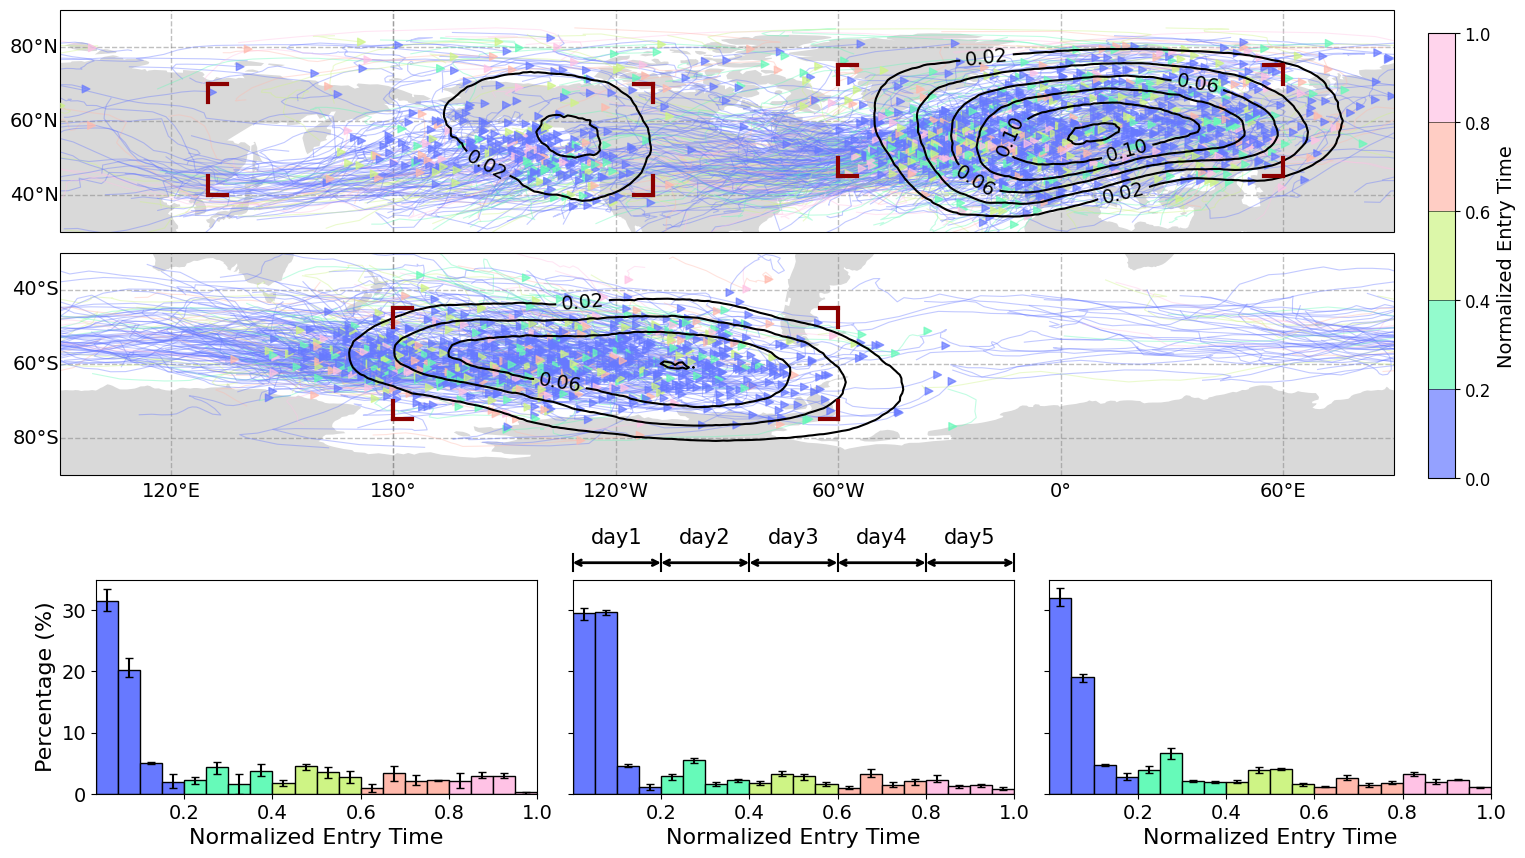

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import BoundaryNorm

def plot_tracks_wrap_connect(ax, track_list, color='black', lw=0.6, alpha=0.3, zorder=2):
    """
    Plot tracks and handle 0/360 wrap by inserting bridge points.
    Each track is a list of (time, lon, lat).
    """
    for track in track_list:
        if len(track) < 2:
            continue

        lons = [float(pt[1]) % 360 for pt in track]
        lats = [float(pt[2]) for pt in track]

        new_lons = [lons[0]]
        new_lats = [lats[0]]

        for i in range(1, len(lons)):
            lon1, lat1 = lons[i - 1], lats[i - 1]
            lon2, lat2 = lons[i], lats[i]

            dlon = lon2 - lon1

            # case 1: e.g. 358 -> 6, should go through 360/0
            if dlon < -300:
                frac = (360 - lon1) / ((360 - lon1) + lon2)
                lat_edge = lat1 + frac * (lat2 - lat1)

                new_lons.extend([360.0, np.nan, 0.0, lon2])
                new_lats.extend([lat_edge, np.nan, lat_edge, lat2])

            # case 2: e.g. 6 -> 358, should go through 0/360
            elif dlon > 300:
                frac = lon1 / (lon1 + (360 - lon2))
                lat_edge = lat1 + frac * (lat2 - lat1)

                new_lons.extend([0.0, np.nan, 360.0, lon2])
                new_lats.extend([lat_edge, np.nan, lat_edge, lat2])

            else:
                new_lons.append(lon2)
                new_lats.append(lat2)

        ax.plot(
            new_lons,
            new_lats,
            color=color,
            linewidth=lw,
            alpha=alpha,
            transform=ccrs.PlateCarree(),
            zorder=zorder
        )

def plot_tracks_wrap_connect_entrycolor(ax, track_list, values, cmap, norm, lw=0.8, alpha=0.4, zorder=2):

    for track, val in zip(track_list, values):
        if len(track) < 2:
            continue

        color = cmap(norm(val))   # color based on the value (e.g., entry time percentage)

        lons = [float(pt[1]) % 360 for pt in track]
        lats = [float(pt[2]) for pt in track]

        new_lons = [lons[0]]
        new_lats = [lats[0]]

        for i in range(1, len(lons)):
            lon1, lat1 = lons[i - 1], lats[i - 1]
            lon2, lat2 = lons[i], lats[i]

            dlon = lon2 - lon1

            if dlon < -300:
                frac = (360 - lon1) / ((360 - lon1) + lon2)
                lat_edge = lat1 + frac * (lat2 - lat1)

                new_lons.extend([360.0, np.nan, 0.0, lon2])
                new_lats.extend([lat_edge, np.nan, lat_edge, lat2])

            elif dlon > 300:
                frac = lon1 / (lon1 + (360 - lon2))
                lat_edge = lat1 + frac * (lat2 - lat1)

                new_lons.extend([0.0, np.nan, 360.0, lon2])
                new_lats.extend([lat_edge, np.nan, lat_edge, lat2])

            else:
                new_lons.append(lon2)
                new_lats.append(lat2)

        ax.plot(
            new_lons,
            new_lats,
            color=color,              # colormap
            linewidth=lw,
            alpha=alpha,
            transform=ccrs.PlateCarree(),
            zorder=zorder
        )

def calc_hist_percent(data, bounds_fine):
    hist_vals, hist_bins = np.histogram(data , bins=bounds_fine)
    hist_vals_percent = hist_vals / hist_vals.sum() * 100
    return hist_vals_percent, hist_bins

def add_brackets(ax, lon_min, lon_max, lat_min, lat_max,
                 dx = 5, dy = 5,
                 color='darkred', lw=3, alpha=1, zorder=12):
    """
    Draw corner brackets for a rectangular region.

    frac_lon, frac_lat control the length of the brackets as a fraction of the rectangle size.
    """

    dlon = lon_max - lon_min
    dlat = lat_max - lat_min

    # bottom-left
    ax.plot([lon_min, lon_min + dx], [lat_min, lat_min],
            color=color, lw=lw, alpha=alpha, transform=pc, zorder=zorder)
    ax.plot([lon_min, lon_min], [lat_min, lat_min + dy],
            color=color, lw=lw, alpha=alpha, transform=pc, zorder=zorder)

    # bottom-right
    ax.plot([lon_max - dx, lon_max], [lat_min, lat_min],
            color=color, lw=lw, alpha=alpha, transform=pc, zorder=zorder)
    ax.plot([lon_max, lon_max], [lat_min, lat_min + dy],
            color=color, lw=lw, alpha=alpha, transform=pc, zorder=zorder)

    # top-left
    ax.plot([lon_min, lon_min + dx], [lat_max, lat_max],
            color=color, lw=lw, alpha=alpha, transform=pc, zorder=zorder)
    ax.plot([lon_min, lon_min], [lat_max - dy, lat_max],
            color=color, lw=lw, alpha=alpha, transform=pc, zorder=zorder)

    # top-right
    ax.plot([lon_max - dx, lon_max], [lat_max, lat_max],
            color=color, lw=lw, alpha=alpha, transform=pc, zorder=zorder)
    ax.plot([lon_max, lon_max], [lat_max - dy, lat_max],
            color=color, lw=lw, alpha=alpha, transform=pc, zorder=zorder)

# =========================
# Figure layout
# =========================
centralLon = 270
proj = ccrs.PlateCarree(central_longitude=centralLon)
pc = ccrs.PlateCarree()

fig = plt.figure(figsize=(18, 10.5))
outer = gridspec.GridSpec(
    nrows=2, ncols=1,
    height_ratios=[2.6, 1.0],
    hspace=0.1
)

# Panel (a): two maps + one shared colorbar
gs_map = gridspec.GridSpecFromSubplotSpec(
    2, 2, subplot_spec=outer[0],
    width_ratios=[30, 0.6],
    height_ratios=[1, 1],
    wspace=0.05, hspace=0.05
)

ax_n = fig.add_subplot(gs_map[0, 0], projection=proj)
ax_s = fig.add_subplot(gs_map[1, 0], projection=proj)
cax = fig.add_subplot(gs_map[:, 1])   # 

# Panel (b): three histograms
gs_hist = gridspec.GridSpecFromSubplotSpec(
    1, 3, subplot_spec=outer[1],
    wspace=0.08
)

ax_h1 = fig.add_subplot(gs_hist[0, 0])
ax_h2 = fig.add_subplot(gs_hist[0, 1])
ax_h3 = fig.add_subplot(gs_hist[0, 2])

# =========================
# Common map settings
# =========================
aalpha = 0.7
bounds = np.arange(0, 1.20, 0.20)
cmap_part = gmtColors.sealand
norm = BoundaryNorm(bounds, ncolors=cmap_part.N)

blklevels = np.arange(0, 0.14, 0.02)[1:]


# =========================
# Panel (a): maps
# =========================

def setup_map(ax, lat_range, show_bottom_labels=True):
    ax.set_extent([-180, 180, lat_range[0], lat_range[1]], crs=pc)

    ax.add_feature(
        cfeature.LAND.with_scale('110m'),
        facecolor='0.85',
        edgecolor='none',
        linewidth=1,
    )

    gl = ax.gridlines(
        crs=pc, draw_labels=True, linewidth=1,
        color='gray', linestyle='--', alpha=0.5
    )
    gl.xlabel_style = {'size': 14}
    gl.ylabel_style = {'size': 14}

    if lat_range[0] >= 0:
        gl.ylocator = mticker.FixedLocator([40, 60, 80])
    else:
        gl.ylocator = mticker.FixedLocator([-80, -60, -40])

    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = show_bottom_labels
    gl.left_labels = True

def plot_map_content(ax):
    cf = ax.contour(
        lon_plot, latglobe, Blk1sum_with0_percentage,
        levels=blklevels, colors='black',
        alpha=1.0, linewidths=1.5,
        transform=pc, zorder=10
    )
    clabels = ax.clabel(
        cf,
        levels=cf.levels[::2],
        inline=True,
        fontsize=14,
        fmt=lambda x: f'{x:.2f}',
        colors='black',
        use_clabeltext=True,
        inline_spacing=5,
        zorder=11
    )
    for t in clabels:
        t.set_alpha(1.0)

    # entry points
    sc = ax.scatter(
        intopoint_lon_ATL, intopoint_lat_ATL,
        c=entrytime_ATL, cmap=cmap_part, norm=norm,
        marker='>', s=30, transform=pc,
        alpha=aalpha, edgecolors='face', zorder=8
    )
    ax.scatter(
        intopoint_lon_NP, intopoint_lat_NP,
        c=entrytime_NP, cmap=cmap_part, norm=norm,
        marker='>', s=30, transform=pc,
        alpha=aalpha, edgecolors='face', zorder=8
    )
    ax.scatter(
        intopoint_lon_SP, intopoint_lat_SP,
        c=entrytime_SP, cmap=cmap_part, norm=norm,
        marker='>', s=30, transform=pc,
        alpha=aalpha, edgecolors='face', zorder=8
    )

    for rgname in regions:
        lat_min, lat_max, lon_min, lon_max = Region_ERA(rgname)
        add_brackets(
            ax,
            lon_min, lon_max,
            lat_min, lat_max,
            dx = 5, dy = 5,
            color='darkred',
            lw=3,
            alpha=1,
            zorder=12
        )

    return sc

setup_map(ax_n, [30, 90], show_bottom_labels=False)
setup_map(ax_s, [-90, -30], show_bottom_labels=True)

sc1 = plot_map_content(ax_n)
plot_map_content(ax_s)

# move a bit
pos_n = ax_n.get_position()
pos_s = ax_s.get_position()

# make the two maps closer
ax_s.set_position([
    pos_s.x0,
    pos_s.y0 + 0.04,   # 
    pos_s.width,
    pos_s.height
])

cb = plt.colorbar(
    sc1, cax=cax, orientation='vertical',
    boundaries=bounds, spacing='proportional', drawedges=True
)
cb.ax.tick_params(labelsize=12)
cb.set_label('Normalized Entry Time', fontsize=14)
pos = cax.get_position()
cax.set_position([pos.x0, pos.y0 + 0.06, pos.width, pos.height * 0.8]) # x0: left, y0: bottom, width, height

# add the tracks and entry time color
plot_tracks_wrap_connect_entrycolor(ax_n, intotracks_ATL, entrytime_ATL, cmap_part, norm)
plot_tracks_wrap_connect_entrycolor(ax_n, intotracks_NP, entrytime_NP, cmap_part, norm)
plot_tracks_wrap_connect_entrycolor(ax_s, intotracks_SP, entrytime_SP, cmap_part, norm)

# =========================
# Panel (b): histograms
# =========================
def addhist_multi(ax_hist, entrytime_dict, region, ylimmax=35, ylab=True, title=None):
    
    bounds_fine = np.arange(0, 1.05, 0.05)   # 0, 0.05, ..., 1
    bin_centers = (bounds_fine[:-1] + bounds_fine[1:]) / 2.0
    bin_widths = np.diff(bounds_fine)

    hist_all = []
    for dtname_i in datasets:
        hist_percent_i, _ = calc_hist_percent(entrytime_dict[dtname_i][region], bounds_fine)
        hist_all.append(hist_percent_i)

    hist_all = np.array(hist_all)

    hist_mean = np.mean(hist_all, axis=0)
    hist_min = np.min(hist_all, axis=0)
    hist_max = np.max(hist_all, axis=0)

    yerr_lower = hist_mean - hist_min
    yerr_upper = hist_max - hist_mean
    yerr = np.vstack([yerr_lower, yerr_upper])

    cmap = sc1.cmap
    colors = cmap(norm(bin_centers))

    ax_hist.bar(
        bin_centers,
        hist_mean,
        width=bin_widths,
        align='center',
        color=colors,
        edgecolor='black',
        yerr=yerr,
        ecolor='black',
        capsize=3,
        linewidth=1
    )

    ax_hist.set_xlim(0, 1.0)
    ax_hist.set_ylim(0, ylimmax)
    ax_hist.set_xticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax_hist.set_xlabel('Normalized Entry Time', fontsize=16)

    if ylab:
        ax_hist.set_ylabel('Percentage (%)', fontsize=16)
    else:
        ax_hist.tick_params(labelleft=False)

    ax_hist.tick_params(labelsize=14)

    if title is not None:
        ax_hist.set_title(title, fontsize=16)

addhist_multi(ax_h1, entrytime_dict, "NP",  ylimmax=35, ylab=True,  title=None)
addhist_multi(ax_h2, entrytime_dict, "SP",  ylimmax=35, ylab=False, title=None)
addhist_multi(ax_h3, entrytime_dict, "ATL", ylimmax=35, ylab=False, title=None)

# move panel b slightly to the right
shift_right = 0.02  # try 0.01 ~ 0.03
for axh in [ax_h1, ax_h2, ax_h3]:
    pos = axh.get_position()
    axh.set_position([pos.x0 + shift_right, pos.y0, pos.width, pos.height])

# add indicating text for the histograms ---------------------------------
# add day brackets above the middle histogram panel
y_arrow = 1.08
y_text  = 1.15

day_edges = np.linspace(0.0, 1.0, 6)
day_labels = ["day1", "day2", "day3", "day4", "day5"]

# === arrows ===
for i in range(5):
    x0 = day_edges[i]
    x1 = day_edges[i+1]
    xc = 0.5 * (x0 + x1)

    ax_h2.annotate(
        "",
        xy=(x1, y_arrow), xytext=(x0, y_arrow),
        xycoords=("data", "axes fraction"),
        textcoords=("data", "axes fraction"),
        arrowprops=dict(
            arrowstyle="<->",
            lw=2,
            color="black",
            shrinkA=0,   # remove the indentation at both ends
            shrinkB=0
        ),
        annotation_clip=False
    )

    ax_h2.text(
        xc, y_text, day_labels[i],
        transform=ax_h2.get_xaxis_transform(),
        ha="center", va="bottom",
        fontsize=15
    )

# === vertical separators ===
for x in day_edges:
    ax_h2.plot(
        [x, x],
        [y_arrow - 0.04, y_arrow + 0.04],   # control the length of the vertical ticks
        transform=ax_h2.get_xaxis_transform(),
        color="black",
        lw=1.5,
        clip_on=False
    )


# plt.savefig(f'./FINAL_figures/{dtname}_Fig1a_relayout.png', dpi=400, bbox_inches='tight')
plt.show()


### Load Composite LWA (at least 2 days before/after)

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import BoundaryNorm

def compute_panel_c_data(datasets, regions, ss):
    """
    Precompute panel c data for all regions and datasets.

    Returns
    -------
    panel_c_data : dict
        panel_c_data[rgname] = {
            "relativetimestep": ...,
            "typeid": ...,
            "type_name": ...,
            "dataset_series": array of shape (n_dataset, time),
            "mean_line": ...,
            "min_line": ...,
            "max_line": ...,
            "Ns": list of event counts for each dataset,
        }
    """
    lenbf = 8
    lenaf = 8
    relativetimestep = np.arange(-lenbf, lenaf + 1)

    type_name = {1: "Ridge", 2: "Trough", 3: "Dipole"}
    typeid = 1   # ridge only

    panel_c_data = {}

    for rgname in regions:
        dataset_series = []
        dataset_Ns = []

        for dtname in datasets:
            OUT_DIR = OUT_DIR_List[dtname]

            if typeid == 3:
                BlkAVGLWAlist_AC = np.load(
                    f'{OUT_DIR}/{dtname}_MiddleEddiesBlkLWAseries_Type{typeid}_{rgname}_{ss}_AC_composites.npy',
                    allow_pickle=True
                )
                BlkAVGLWAlist_CC = np.load(
                    f'{OUT_DIR}/{dtname}_MiddleEddiesBlkLWAseries_Type{typeid}_{rgname}_{ss}_CC_composites.npy',
                    allow_pickle=True
                )
                BlkAVGLWAlist = np.concatenate([BlkAVGLWAlist_AC, BlkAVGLWAlist_CC], axis=0)
            else:
                cyc = 'AC' if typeid == 1 else 'CC'
                BlkAVGLWAlist = np.load(
                    f'{OUT_DIR}/{dtname}_MiddleEddiesBlkLWAseries_Type{typeid}_{rgname}_{ss}_{cyc}_composites.npy',
                    allow_pickle=True
                )

            BlkAVGLWAarr = np.nanmean(np.array(BlkAVGLWAlist), axis=0)
            dataset_series.append(BlkAVGLWAarr)
            dataset_Ns.append(len(BlkAVGLWAlist))

        dataset_series = np.array(dataset_series)

        panel_c_data[rgname] = {
            "relativetimestep": relativetimestep,
            "typeid": typeid,
            "type_name": type_name[typeid],
            "dataset_series": dataset_series,
            "mean_line": np.nanmean(dataset_series, axis=0),
            "min_line": np.nanmin(dataset_series, axis=0),
            "max_line": np.nanmax(dataset_series, axis=0),
            "Ns": dataset_Ns,
            "datasets": datasets.copy()
        }

    return panel_c_data
    
def plot_panel_c(ax, panel_c_data, rgname, show_ylabel=True):
    data = panel_c_data[rgname]

    relativetimestep = data["relativetimestep"]
    mean_line = data["mean_line"]
    min_line = data["min_line"]
    max_line = data["max_line"]
    dataset_series = data["dataset_series"]
    type_name = data["type_name"]
    Ns = data["Ns"]
    datasets_local = data["datasets"]

    ax.plot(relativetimestep, mean_line, color='black', linewidth=3)
    ax.fill_between(relativetimestep, min_line, max_line, color='gray', alpha=0.3)
    ax.axvline(0, color="black", linestyle="--", linewidth=1.5)

    ax.set_ylim(np.nanmin(dataset_series) * 0.95, np.nanmax(dataset_series) * 1.03)

    # N_text = ", ".join([f"{dt}:{n}" for dt, n in zip(datasets_local, Ns)])
    # ax.set_title(f"{rgname}  ({type_name}; N={N_text})", fontsize=16)
    N_mean = int(np.round(np.mean(Ns)))
    ax.text(
        0.02, 0.95,                      # upper left corner
        f"N = {N_mean}",
        transform=ax.transAxes,
        ha='left', va='top',
        fontsize=14
    )
    ax.tick_params(axis="x", labelsize=14)
    ax.tick_params(axis="y", labelsize=14)

    # x-axis: convert 6-hourly steps to relative day labels
    ax.set_xticks([-8, -4, 0, 4, 8])
    ax.set_xticklabels([-2, -1, 0, 1, 2])

    if show_ylabel:
        ax.set_ylabel("LWA (10$^8$ m$^2$)", fontsize=18)
    else:
        ax.set_ylabel("")
        ax.tick_params(axis="y", labelleft=False)

panel_c_data = compute_panel_c_data(datasets, ['NP', 'SP', 'ATL'], ss)

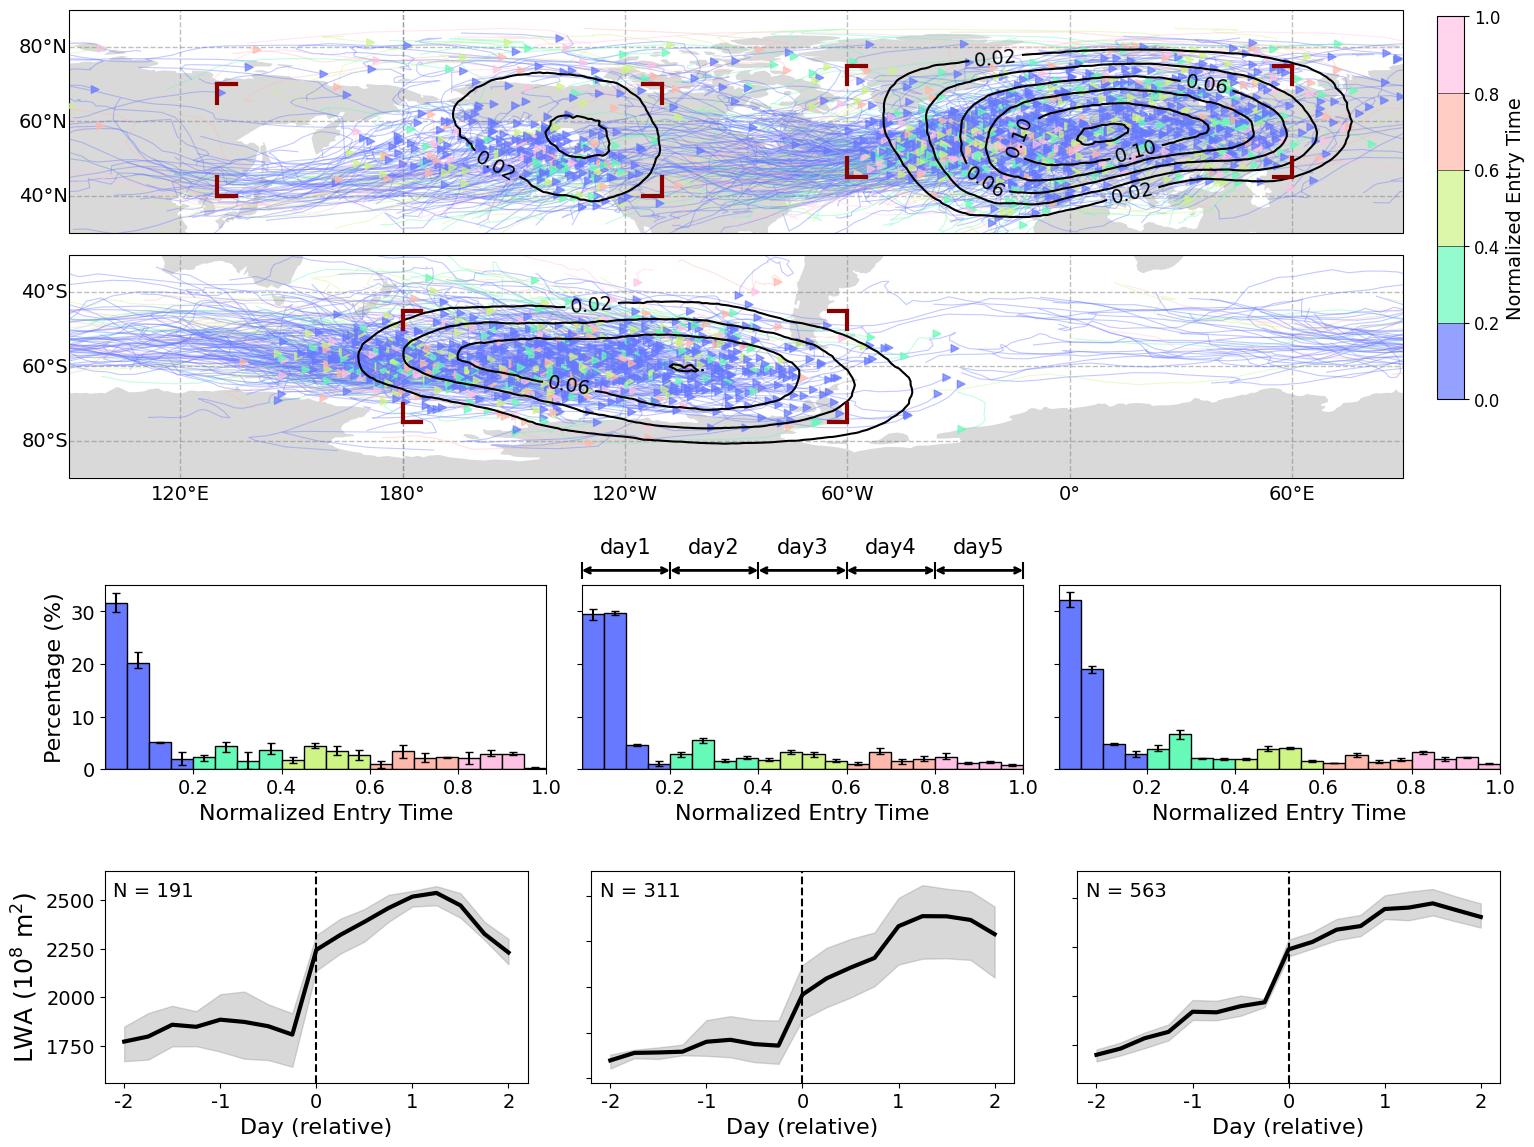

In [11]:

# =========================================================
# helper functions
# =========================================================
def plot_tracks_wrap_connect(ax, track_list, color='black', lw=0.6, alpha=0.3, zorder=2):
    for track in track_list:
        if len(track) < 2:
            continue

        lons = [float(pt[1]) % 360 for pt in track]
        lats = [float(pt[2]) for pt in track]

        new_lons = [lons[0]]
        new_lats = [lats[0]]

        for i in range(1, len(lons)):
            lon1, lat1 = lons[i - 1], lats[i - 1]
            lon2, lat2 = lons[i], lats[i]
            dlon = lon2 - lon1

            if dlon < -300:
                frac = (360 - lon1) / ((360 - lon1) + lon2)
                lat_edge = lat1 + frac * (lat2 - lat1)
                new_lons.extend([360.0, np.nan, 0.0, lon2])
                new_lats.extend([lat_edge, np.nan, lat_edge, lat2])

            elif dlon > 300:
                frac = lon1 / (lon1 + (360 - lon2))
                lat_edge = lat1 + frac * (lat2 - lat1)
                new_lons.extend([0.0, np.nan, 360.0, lon2])
                new_lats.extend([lat_edge, np.nan, lat_edge, lat2])

            else:
                new_lons.append(lon2)
                new_lats.append(lat2)

        ax.plot(
            new_lons, new_lats,
            color=color, linewidth=lw, alpha=alpha,
            transform=ccrs.PlateCarree(), zorder=zorder
        )

def plot_tracks_wrap_connect_entrycolor(ax, track_list, values, cmap, norm, lw=0.8, alpha=0.4, zorder=2):
    for track, val in zip(track_list, values):
        if len(track) < 2:
            continue

        color = cmap(norm(val))

        lons = [float(pt[1]) % 360 for pt in track]
        lats = [float(pt[2]) for pt in track]

        new_lons = [lons[0]]
        new_lats = [lats[0]]

        for i in range(1, len(lons)):
            lon1, lat1 = lons[i - 1], lats[i - 1]
            lon2, lat2 = lons[i], lats[i]
            dlon = lon2 - lon1

            if dlon < -300:
                frac = (360 - lon1) / ((360 - lon1) + lon2)
                lat_edge = lat1 + frac * (lat2 - lat1)
                new_lons.extend([360.0, np.nan, 0.0, lon2])
                new_lats.extend([lat_edge, np.nan, lat_edge, lat2])

            elif dlon > 300:
                frac = lon1 / (lon1 + (360 - lon2))
                lat_edge = lat1 + frac * (lat2 - lat1)
                new_lons.extend([0.0, np.nan, 360.0, lon2])
                new_lats.extend([lat_edge, np.nan, lat_edge, lat2])

            else:
                new_lons.append(lon2)
                new_lats.append(lat2)

        ax.plot(
            new_lons, new_lats,
            color=color, linewidth=lw, alpha=alpha,
            transform=ccrs.PlateCarree(), zorder=zorder
        )

def calc_hist_percent(data, bounds_fine):
    hist_vals, hist_bins = np.histogram(data, bins=bounds_fine)
    hist_vals_percent = hist_vals / hist_vals.sum() * 100
    return hist_vals_percent, hist_bins

def add_brackets(ax, lon_min, lon_max, lat_min, lat_max,
                 dx=5, dy=5, color='darkred', lw=3, alpha=1, zorder=12):
    ax.plot([lon_min, lon_min + dx], [lat_min, lat_min], color=color, lw=lw, alpha=alpha, transform=pc, zorder=zorder)
    ax.plot([lon_min, lon_min], [lat_min, lat_min + dy], color=color, lw=lw, alpha=alpha, transform=pc, zorder=zorder)

    ax.plot([lon_max - dx, lon_max], [lat_min, lat_min], color=color, lw=lw, alpha=alpha, transform=pc, zorder=zorder)
    ax.plot([lon_max, lon_max], [lat_min, lat_min + dy], color=color, lw=lw, alpha=alpha, transform=pc, zorder=zorder)

    ax.plot([lon_min, lon_min + dx], [lat_max, lat_max], color=color, lw=lw, alpha=alpha, transform=pc, zorder=zorder)
    ax.plot([lon_min, lon_min], [lat_max - dy, lat_max], color=color, lw=lw, alpha=alpha, transform=pc, zorder=zorder)

    ax.plot([lon_max - dx, lon_max], [lat_max, lat_max], color=color, lw=lw, alpha=alpha, transform=pc, zorder=zorder)
    ax.plot([lon_max, lon_max], [lat_max - dy, lat_max], color=color, lw=lw, alpha=alpha, transform=pc, zorder=zorder)

def setup_map(ax, lat_range, show_bottom_labels=True):
    ax.set_extent([-180, 180, lat_range[0], lat_range[1]], crs=pc)
    ax.add_feature(
        cfeature.LAND.with_scale('110m'),
        facecolor='0.85',
        edgecolor='none',
        linewidth=1,
    )

    gl = ax.gridlines(
        crs=pc, draw_labels=True, linewidth=1,
        color='gray', linestyle='--', alpha=0.5
    )
    gl.xlabel_style = {'size': 14}
    gl.ylabel_style = {'size': 14}

    if lat_range[0] >= 0:
        gl.ylocator = mticker.FixedLocator([40, 60, 80])
    else:
        gl.ylocator = mticker.FixedLocator([-80, -60, -40])

    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = show_bottom_labels
    gl.left_labels = True

def plot_map_content(ax):
    cf = ax.contour(
        lon_plot, latglobe, Blk1sum_with0_percentage,
        levels=blklevels, colors='black',
        alpha=1.0, linewidths=1.5,
        transform=pc, zorder=10
    )
    clabels = ax.clabel(
        cf,
        levels=cf.levels[::2],
        inline=True,
        fontsize=14,
        fmt=lambda x: f'{x:.2f}',
        colors='black',
        use_clabeltext=True,
        inline_spacing=5,
        zorder=11
    )
    for t in clabels:
        t.set_alpha(1.0)

    sc = ax.scatter(
        intopoint_lon_ATL, intopoint_lat_ATL,
        c=entrytime_ATL, cmap=cmap_part, norm=norm,
        marker='>', s=30, transform=pc,
        alpha=aalpha, edgecolors='face', zorder=8
    )
    ax.scatter(
        intopoint_lon_NP, intopoint_lat_NP,
        c=entrytime_NP, cmap=cmap_part, norm=norm,
        marker='>', s=30, transform=pc,
        alpha=aalpha, edgecolors='face', zorder=8
    )
    ax.scatter(
        intopoint_lon_SP, intopoint_lat_SP,
        c=entrytime_SP, cmap=cmap_part, norm=norm,
        marker='>', s=30, transform=pc,
        alpha=aalpha, edgecolors='face', zorder=8
    )

    for rgname in regions:
        lat_min, lat_max, lon_min, lon_max = Region_ERA(rgname)
        add_brackets(ax, lon_min, lon_max, lat_min, lat_max,
                     dx=5, dy=5, color='darkred', lw=3, alpha=1, zorder=12)
    return sc

def addhist_multi(ax_hist, entrytime_dict, region, ylimmax=35, ylab=True, title=None):
    bounds_fine = np.arange(0, 1.05, 0.05)
    bin_centers = (bounds_fine[:-1] + bounds_fine[1:]) / 2.0
    bin_widths = np.diff(bounds_fine)

    hist_all = []
    for dtname_i in datasets:
        hist_percent_i, _ = calc_hist_percent(entrytime_dict[dtname_i][region], bounds_fine)
        hist_all.append(hist_percent_i)

    hist_all = np.array(hist_all)
    hist_mean = np.mean(hist_all, axis=0)
    hist_min = np.min(hist_all, axis=0)
    hist_max = np.max(hist_all, axis=0)

    yerr_lower = hist_mean - hist_min
    yerr_upper = hist_max - hist_mean
    yerr = np.vstack([yerr_lower, yerr_upper])

    cmap = sc1.cmap
    colors = cmap(norm(bin_centers))

    ax_hist.bar(
        bin_centers, hist_mean,
        width=bin_widths, align='center',
        color=colors, edgecolor='black',
        yerr=yerr, ecolor='black', capsize=3, linewidth=1
    )

    ax_hist.set_xlim(0, 1.0)
    ax_hist.set_ylim(0, ylimmax)
    ax_hist.set_xticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax_hist.set_xlabel('Normalized Entry Time', fontsize=16)

    if ylab:
        ax_hist.set_ylabel('Percentage (%)', fontsize=16)
    else:
        ax_hist.tick_params(labelleft=False)

    ax_hist.tick_params(labelsize=14)
    if title is not None:
        ax_hist.set_title(title, fontsize=16)

# =========================================================
# figure layout
# =========================================================
centralLon = 270
proj = ccrs.PlateCarree(central_longitude=centralLon)
pc = ccrs.PlateCarree()

fig = plt.figure(figsize=(18, 14))
outer = gridspec.GridSpec(
    nrows=3, ncols=1,
    height_ratios=[2.6, 1.0, 1.15],
    hspace=0.35
)

# 00 set the common layout for all panels ----------------------------------    
# -------- panel a --------
gs_map = gridspec.GridSpecFromSubplotSpec(
    2, 2, subplot_spec=outer[0],
    width_ratios=[30, 0.6],
    height_ratios=[1, 1],
    wspace=0.05, hspace=0.05
)

ax_n = fig.add_subplot(gs_map[0, 0], projection=proj)
ax_s = fig.add_subplot(gs_map[1, 0], projection=proj)
cax = fig.add_subplot(gs_map[:, 1])

# -------- panel b --------
gs_hist = gridspec.GridSpecFromSubplotSpec(
    1, 3, subplot_spec=outer[1],
    wspace=0.08
)
ax_h1 = fig.add_subplot(gs_hist[0, 0])
ax_h2 = fig.add_subplot(gs_hist[0, 1])
ax_h3 = fig.add_subplot(gs_hist[0, 2])

# -------- panel c --------
gs_c = gridspec.GridSpecFromSubplotSpec(
    1, 3, subplot_spec=outer[2],
    wspace=0.15
)

ax_c1 = fig.add_subplot(gs_c[0, 0])
ax_c2 = fig.add_subplot(gs_c[0, 1])
ax_c3 = fig.add_subplot(gs_c[0, 2])

# =========================================================
# panel a
# =========================================================
aalpha = 0.7
bounds = np.arange(0, 1.20, 0.20)
cmap_part = gmtColors.sealand
norm = BoundaryNorm(bounds, ncolors=cmap_part.N)
blklevels = np.arange(0, 0.14, 0.02)[1:]

setup_map(ax_n, [30, 90], show_bottom_labels=False)
setup_map(ax_s, [-90, -30], show_bottom_labels=True)

sc1 = plot_map_content(ax_n)
plot_map_content(ax_s)

# # move two maps closer
# pos_s = ax_s.get_position()
# ax_s.set_position([pos_s.x0, pos_s.y0 + 0.04, pos_s.width, pos_s.height])

cb = plt.colorbar(
    sc1, cax=cax, orientation='vertical',
    boundaries=bounds, spacing='proportional', drawedges=True
)
cb.ax.tick_params(labelsize=12)
cb.set_label('Normalized Entry Time', fontsize=14)

pos = cax.get_position()
cax.set_position([pos.x0, pos.y0 + 0.06, pos.width, pos.height * 0.8])

plot_tracks_wrap_connect_entrycolor(ax_n, intotracks_ATL, entrytime_ATL, cmap_part, norm)
plot_tracks_wrap_connect_entrycolor(ax_n, intotracks_NP, entrytime_NP, cmap_part, norm)
plot_tracks_wrap_connect_entrycolor(ax_s, intotracks_SP, entrytime_SP, cmap_part, norm)

# =========================================================
# panel b
# =========================================================
addhist_multi(ax_h1, entrytime_dict, "NP",  ylimmax=35, ylab=True,  title=None)
addhist_multi(ax_h2, entrytime_dict, "SP",  ylimmax=35, ylab=False, title=None)
addhist_multi(ax_h3, entrytime_dict, "ATL", ylimmax=35, ylab=False, title=None)

shift_right = 0.02
for axh in [ax_h1, ax_h2, ax_h3]:
    pos = axh.get_position()
    axh.set_position([pos.x0 + shift_right, pos.y0, pos.width, pos.height])

# shift_up = 0.03  
# for axh in [ax_h1, ax_h2, ax_h3]:
#     pos = axh.get_position()
#     axh.set_position([pos.x0, pos.y0 + shift_up, pos.width, pos.height])

y_arrow = 1.08
y_text  = 1.15
day_edges = np.linspace(0.0, 1.0, 6)
day_labels = ["day1", "day2", "day3", "day4", "day5"]

for i in range(5):
    x0 = day_edges[i]
    x1 = day_edges[i+1]
    xc = 0.5 * (x0 + x1)

    ax_h2.annotate(
        "",
        xy=(x1, y_arrow), xytext=(x0, y_arrow),
        xycoords=("data", "axes fraction"),
        textcoords=("data", "axes fraction"),
        arrowprops=dict(arrowstyle="<->", lw=2, color="black", shrinkA=0, shrinkB=0),
        annotation_clip=False
    )

    ax_h2.text(
        xc, y_text, day_labels[i],
        transform=ax_h2.get_xaxis_transform(),
        ha="center", va="bottom", fontsize=15
    )

for x in day_edges:
    ax_h2.plot(
        [x, x],
        [y_arrow - 0.04, y_arrow + 0.04],
        transform=ax_h2.get_xaxis_transform(),
        color="black", lw=1.5, clip_on=False
    )

# =========================================================
# panel c
# =========================================================
plot_panel_c(ax_c1, panel_c_data, 'NP', show_ylabel=True)
plot_panel_c(ax_c2, panel_c_data, 'SP', show_ylabel=False)
plot_panel_c(ax_c3, panel_c_data, 'ATL', show_ylabel=False)
ax_c1.set_xlabel("Day (relative)", fontsize=16)
ax_c2.set_xlabel("Day (relative)", fontsize=16)
ax_c3.set_xlabel("Day (relative)", fontsize=16)

shift_right = 0.02
for axh in [ax_c1, ax_c2, ax_c3]:
    pos = axh.get_position()
    axh.set_position([pos.x0 + shift_right, pos.y0, pos.width, pos.height])

plt.savefig('./FINAL_figures/Nature_Fig1.png', dpi=300, bbox_inches='tight')
plt.show()